# 04 — Ensemble models

Phase 4: **Random Forest** and **XGBoost** with depth constraints (no grid search).

| Model | Settings |
|-------|----------|
| Random Forest | `n_estimators=200`, `max_depth=12`, `min_samples_leaf=5`, `n_jobs=-1`, `random_state=42` |
| XGBoost | `n_estimators=200`, `max_depth=6`, `learning_rate=0.1`, `eval_metric=logloss`, `random_state=42` |

Same Phase 2 arrays as Phase 3. **`models/preprocessor.pkl` is not refit.** No production-model choice (Phase 7).

Script: `ml/train.py` → `run_ensembles()`.

In [1]:
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay

ROOT = Path.cwd()
if not (ROOT / "ml" / "train.py").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from ml.train import PHASE3_SIGNAL_FEATURES, run_ensembles

sns.set_theme(style="whitegrid")
FIG = ROOT / "reports" / "figures"
FIG.mkdir(parents=True, exist_ok=True)
print("ROOT:", ROOT)

ROOT: g:\SLIIT Academy\6th Semester\FDM\FDM Project\FDM_Project


## 1. Fit ensembles and four-model table

Loads existing Phase 3 pickles for LR/DT (does not change the preprocessor). Trains RF and XGBoost. Writes `reports/model_comparison.csv` sorted by test ROC-AUC.

In [2]:
pre = ROOT / "models" / "preprocessor.pkl"
mtime_before = pre.stat().st_mtime
result = run_ensembles()
assert pre.stat().st_mtime == mtime_before, "preprocessor.pkl must not change in Phase 4"

display(result["comparison"].round(4))

Phase 4 complete (ensembles; preprocessor.pkl not modified; no final-model pick).
              model  accuracy  precision  recall     f1  roc_auc  train_roc_auc  roc_auc_gap  overfit_flag
      Random Forest    0.5706     0.5653  0.4127 0.4771   0.5940         0.7332       0.1393          True
Logistic Regression    0.5665     0.5553  0.4350 0.4878   0.5898         0.5891      -0.0007         False
            XGBoost    0.5669     0.5535  0.4522 0.4978   0.5892         0.6943       0.1050          True
      Decision Tree    0.5184     0.4927  0.4942 0.4934   0.5173         1.0000       0.4827          True
  Random Forest train AUC=0.7332  test AUC=0.5940  gap=0.1393  FLAG gap>0.05
  Random Forest confusion matrix: [[14991, 6025], [11149, 7835]]
  XGBoost train AUC=0.6943  test AUC=0.5892  gap=0.1050  FLAG gap>0.05
  XGBoost confusion matrix: [[14092, 6924], [10399, 8585]]
RF top 10 importances:
                    feature  importance
   num__delivery_delay_days    0.098600
      nu

,model,accuracy,precision,recall,f1,roc_auc,train_roc_auc,roc_auc_gap,overfit_flag
0,Random Forest,0.5706,0.5653,0.4127,0.4771,0.5940,0.7332,0.1393,True
1,Logistic Regression,0.5665,0.5553,0.4350,0.4878,0.5898,0.5891,-0.0007,False
2,XGBoost,0.5669,0.5535,0.4522,0.4978,0.5892,0.6943,0.1050,True
3,Decision Tree,0.5184,0.4927,0.4942,0.4934,0.5173,1.0000,0.4827,True


## 2. Confusion matrices and overfitting check

Flag if **train ROC-AUC − test ROC-AUC > 0.05**.

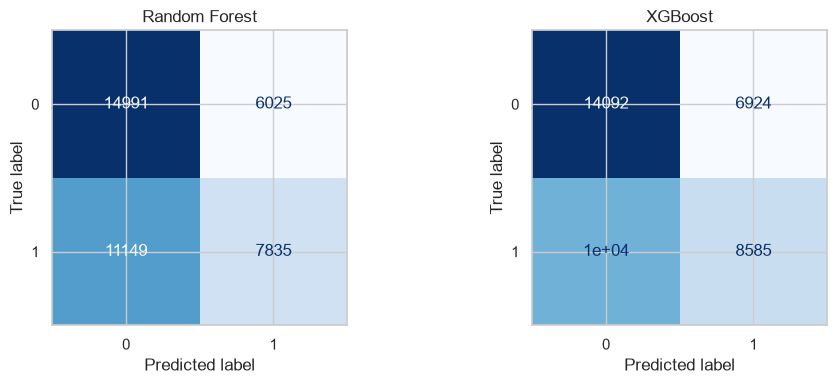

,model,train_roc_auc,roc_auc,roc_auc_gap,overfit_flag
0,Random Forest,0.7332,0.5940,0.1393,True
1,Logistic Regression,0.5891,0.5898,-0.0007,False
2,XGBoost,0.6943,0.5892,0.1050,True
3,Decision Tree,1.0000,0.5173,0.4827,True


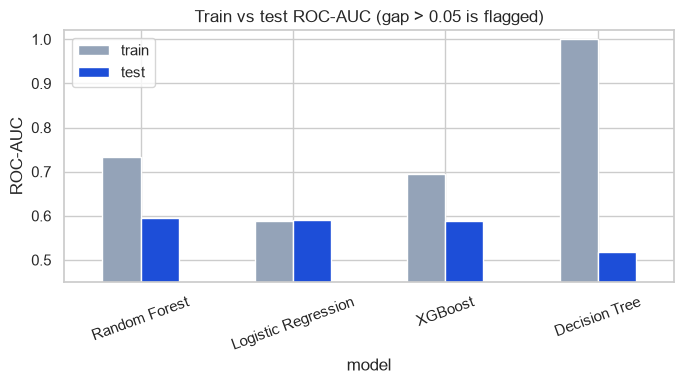

In [3]:
X_test = np.load(ROOT / "dataset" / "processed" / "X_test.npy")
y_test = np.load(ROOT / "dataset" / "processed" / "y_test.npy")
rf = joblib.load(ROOT / "models" / "random_forest.pkl")
xgb = joblib.load(ROOT / "models" / "xgboost.pkl")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, model, title in [(axes[0], rf, "Random Forest"), (axes[1], xgb, "XGBoost")]:
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(title)
fig.tight_layout()
fig.savefig(FIG / "10_ensemble_confusion_matrices.png", bbox_inches="tight", dpi=150)
plt.show()

gap = result["comparison"][["model", "train_roc_auc", "roc_auc", "roc_auc_gap", "overfit_flag"]]
display(gap.round(4))

fig, ax = plt.subplots(figsize=(7, 4))
plot = result["comparison"].set_index("model")[["train_roc_auc", "roc_auc"]]
plot.plot(kind="bar", ax=ax, color=["#94a3b8", "#1d4ed8"], rot=20)
ax.set_ylabel("ROC-AUC")
ax.set_title("Train vs test ROC-AUC (gap > 0.05 is flagged)")
ax.legend(["train", "test"])
ax.set_ylim(0.45, 1.02)
fig.tight_layout()
fig.savefig(FIG / "11_train_vs_test_roc_auc.png", bbox_inches="tight", dpi=150)
plt.show()

**Overfitting:** Constraining depth helped vs Phase 3’s unpruned tree (train AUC 1.0), but RF (gap ~0.14) and XGBoost (gap ~0.11) still **overfit by the 0.05 rule**. Logistic Regression’s train and test AUC are essentially equal. Phase 6 tuning (shallower trees, stronger `min_samples_leaf` / regularization) is the place to shrink those gaps — not a final-model pick yet.

## 3. Feature importances vs Phase 3

Phase 3 LR pushed **toward return** with: `used_coupon`, clothing, express, apple_pay, desktop. If ensembles rank the same features highly, that signal is not an LR-only artifact.

Unpruned DT importances in Phase 3 were almost all **numeric** (delay, discount, session, …).

RF top 10


,feature,importance
0,num__delivery_delay_days,0.0986
1,num__discount_percent,0.0907
2,num__session_length_minutes,0.0900
3,num__product_price,0.0897
4,num__past_return_rate,0.0884
5,num__product_rating,0.0799
6,num__customer_age,0.0685
7,num__num_product_views,0.0617
8,num__past_purchase_count,0.0537
9,bin__used_coupon,0.0431


XGB top 10


,feature,importance
0,cat__shipping_method_express,0.1518
1,bin__used_coupon,0.1076
2,cat__product_category_electronics,0.0908
3,cat__device_type_mobile,0.0709
4,cat__payment_method_apple_pay,0.0692
5,cat__product_category_clothing,0.0502
6,cat__device_type_desktop,0.0476
7,cat__product_category_toys,0.0365
8,cat__payment_method_debit_card,0.0289
9,cat__product_category_home,0.0288


Phase 3 signal in RF top 10: {'bin__used_coupon': True, 'cat__product_category_clothing': False, 'cat__shipping_method_express': False, 'cat__payment_method_apple_pay': False, 'cat__device_type_desktop': False}
Phase 3 signal in XGB top 10: {'bin__used_coupon': True, 'cat__product_category_clothing': True, 'cat__shipping_method_express': True, 'cat__payment_method_apple_pay': True, 'cat__device_type_desktop': True}


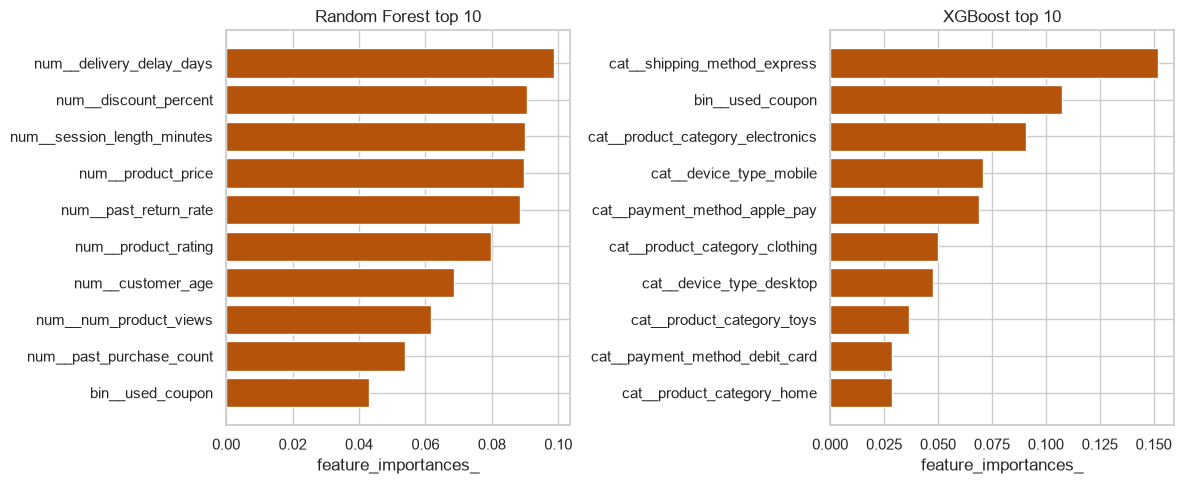

,feature,LR_coef,DT_rank,RF_rank,XGB_rank
0,bin__used_coupon,0.274879,23,10,2
1,cat__product_category_clothing,0.265694,24,15,6
2,cat__shipping_method_express,0.205546,21,11,1
3,cat__payment_method_apple_pay,0.146501,16,13,5
4,cat__device_type_desktop,0.105756,19,17,7


In [4]:
rf_imp = result["rf_importances"]
xgb_imp = result["xgb_importances"]
dt_imp = result["dt_importances"]
lr_coef = result["lr_coefficients"]

print("RF top 10")
display(rf_imp.head(10).round(4))
print("XGB top 10")
display(xgb_imp.head(10).round(4))

print("Phase 3 signal in RF top 10:", result["rf_signal_in_top10"])
print("Phase 3 signal in XGB top 10:", result["xgb_signal_in_top10"])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, table, title in [
    (axes[0], rf_imp.head(10).iloc[::-1], "Random Forest top 10"),
    (axes[1], xgb_imp.head(10).iloc[::-1], "XGBoost top 10"),
]:
    ax.barh(table["feature"], table["importance"], color="#b45309")
    ax.set_title(title)
    ax.set_xlabel("feature_importances_")
fig.tight_layout()
fig.savefig(FIG / "12_ensemble_importances.png", bbox_inches="tight", dpi=150)
plt.show()

rank_rows = []
for feat in PHASE3_SIGNAL_FEATURES:
    rank_rows.append(
        {
            "feature": feat,
            "LR_coef": float(lr_coef.loc[lr_coef.feature == feat, "coefficient"].iloc[0]),
            "DT_rank": int(dt_imp.index[dt_imp.feature == feat][0] + 1),
            "RF_rank": int(rf_imp.index[rf_imp.feature == feat][0] + 1),
            "XGB_rank": int(xgb_imp.index[xgb_imp.feature == feat][0] + 1),
        }
    )
display(pd.DataFrame(rank_rows))

**Is the Phase 3 story real?**

- **XGBoost (gain importances):** all five LR “toward return” features are in the **top 10**, together with electronics / mobile (the LR *negative* category counterparts). That **confirms the EDA/LR category+coupon signal** rather than treating it as a linear-model quirk.
- **Random Forest (Gini importances):** still dominated by **continuous** columns, like the unpruned DT — only `used_coupon` from that list makes the top 10. Gini on many-level numerics is a known bias; it does **not** mean clothing/express are useless.
- **Decision Tree (Phase 3):** same numeric bias, worse because it was unpruned.

Test ROC-AUC is tightly bunched (RF ≈ 0.594, LR ≈ 0.590, XGB ≈ 0.589). Do **not** pick a winner here; Phase 6 should tune RF/XGB (and maybe LR `C`) with the overfit gap in mind.

## Outputs

| Path | Role |
|------|------|
| `models/random_forest.pkl` | Fitted RF |
| `models/xgboost.pkl` | Fitted XGBoost |
| `reports/model_comparison.csv` | LR, DT, RF, XGB sorted by test ROC-AUC |
| `reports/rf_importances.csv` | All RF importances |
| `reports/xgboost_importances.csv` | All XGB importances |